In [1]:
import scarf

scarf.set_verbosity('WARNING')

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
)
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
).dump(batch_size=1000)

Minimum cell count (502) is lower than size factor multiplier (1000)



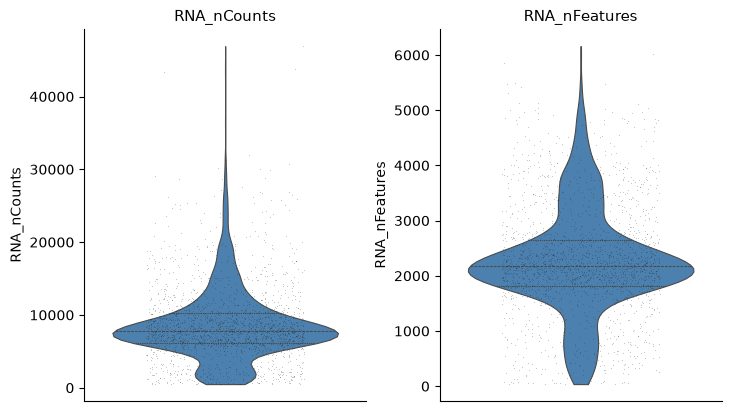

In [2]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.plots.distribution(
    keys=['RNA_nCounts', 'RNA_nFeatures'],
    kind='violin',
    max_points=2000,
)

In [3]:
artifacts = ds.pipeline.run(
    pipeline_id='basic_rna_analysis',
    filtering={
        'method': 'manual',
        'attrs': ['RNA_nCounts', 'RNA_nFeatures'],
        'highs': [15000, 4000],
        'lows': [1000, 500],
    },
    cell_cycle_scoring=False,
    highly_variable_features={
        'min_cells': 20,
        'top_n': 500,
        'show_plot': False,
    },
    pca={'dims': 15, 'n_centroids': 100},
    neighbors={'k': 11},
    umap={
        'n_epochs': 250,
        'spread': 5,
        'min_dist': 1,
        'parallel': True,
    },
    leiden={0.5: {'label': 'leiden_cluster'}},
    paris=False,
    doublet_scoring=False,
    markers=False,
)
list(artifacts)

['cell_selection',
 'highly_variable_features',
 'normalized',
 'pca',
 'ann_index',
 'neighbors',
 'connectivity_map',
 'embedding_initialization',
 'umap',
 'leiden_0.5']

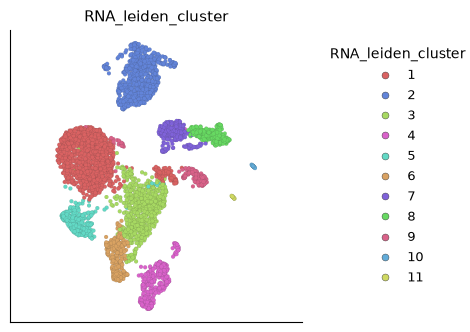

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [5]:
print('Artifact kinds:', sorted({ref.kind for ref in ds.list_artifacts()}))

status = ds.inspect_artifact(artifacts['connectivity_map'])
print('Graph complete:', status.complete)
print('Graph operation:', status.operation)
print('Graph parameters:', status.parameters)

Artifact kinds: ['ann_index', 'cluster_labels', 'connectivity_map', 'embedding', 'embedding_initialization', 'feature_scaling', 'feature_selection', 'neighbors', 'normalized', 'reduction']
Graph complete: True
Graph operation: build_connectivity_map
Graph parameters: {'local_connectivity': 1.0, 'bandwidth': 1.5}
